In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns


In [3]:
df = pd.read_csv("data/Sample - Superstore.csv", encoding="latin1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [11]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(9994, 21)
Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [17]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [18]:
df.dtypes

Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code               int64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

In [24]:

df[["Sales", "Profit", "Discount", "Quantity"]].describe()

,Sales,Profit,Discount,Quantity
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,28.656896,0.156203,3.789574
std,623.245101,234.260108,0.206452,2.225110
min,0.444000,-6599.978000,0.000000,1.000000
25%,17.280000,1.728750,0.000000,2.000000
50%,54.490000,8.666500,0.200000,3.000000
75%,209.940000,29.364000,0.200000,5.000000
max,22638.480000,8399.976000,0.800000,14.000000


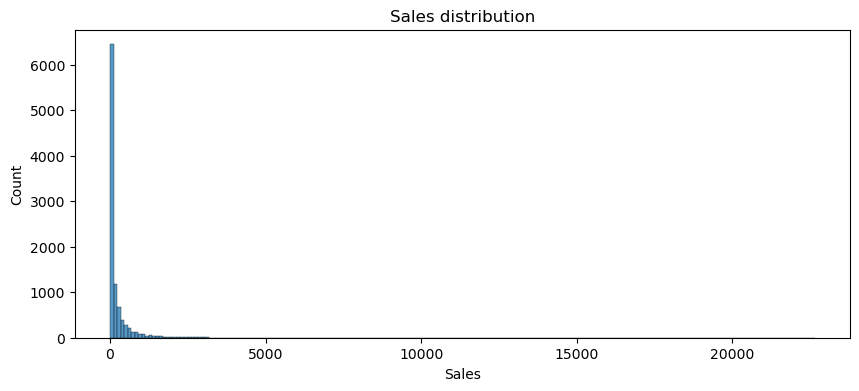

In [28]:
plt.figure(figsize=(10, 4))
sns.histplot(data=df, x="Sales")
plt.title("Sales distribution")
plt.show()

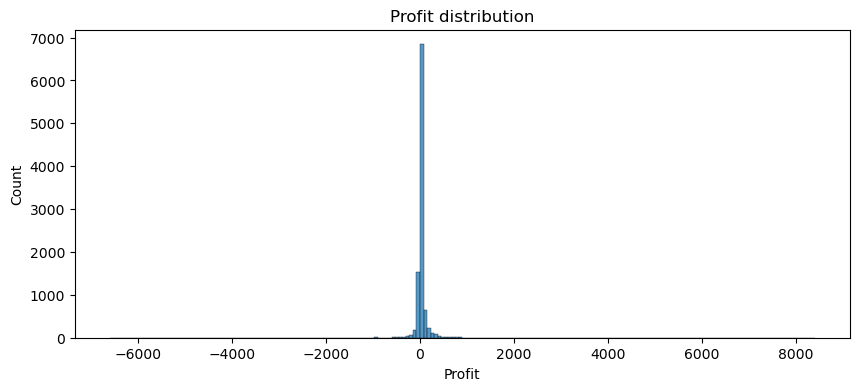

In [32]:
plt.figure(figsize=(10,4))
sns.histplot(data=df, x="Profit")
plt.title("Profit distribution")
plt.show()

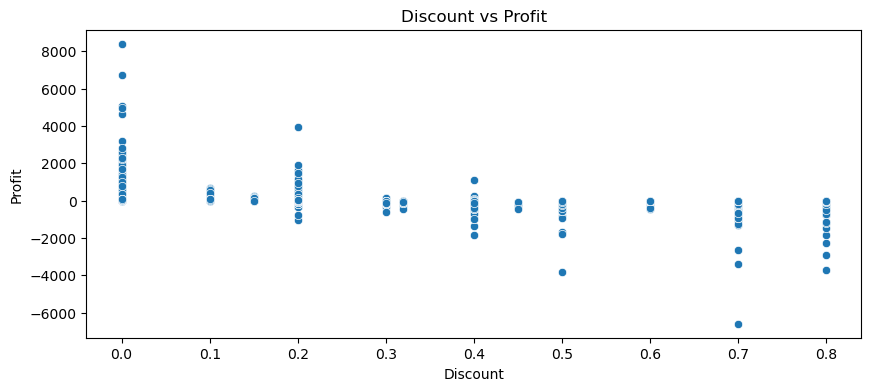

In [75]:
plt.figure(figsize=(10, 4))
sns.scatterplot(data=df, x="Discount", y="Profit")
plt.title("Discount vs Profit")
plt.show()

In [36]:
Discount = df.groupby("Discount")["Profit"].mean()
Discount

Discount
0.00     66.900292
0.10     96.055074
0.15     27.288298
0.20     24.702572
0.30    -45.679636
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -101.796797
Name: Profit, dtype: float64

In [ ]:
avg_profit_by_cat = df.groupby("Category")["Profit"].mean()
avg_profit_by_cat

Category
Furniture           8.699327
Office Supplies    20.327050
Technology         78.752002
Name: Profit, dtype: float64

In [48]:
Cat_metric = df.groupby("Category")["Profit"].agg(["mean", "count"])
Cat_metric 


,mean,count
Category,,
Furniture,8.699327,2121
Office Supplies,20.327050,6026
Technology,78.752002,1847


In [56]:
total_profit_by_cat = df.groupby("Category")["Profit"].sum()
total_profit_by_cat

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64

In [65]:
df["YearMonth"] = df["Order Date"].dt.to_period("M")
monthly_sales = df.groupby("YearMonth")["Sales"].sum()
monthly_sales

YearMonth
2014-01     14236.8950
2014-02      4519.8920
2014-03     55691.0090
2014-04     28295.3450
2014-05     23648.2870
2014-06     34595.1276
2014-07     33946.3930
2014-08     27909.4685
2014-09     81777.3508
2014-10     31453.3930
2014-11     78628.7167
2014-12     69545.6205
2015-01     18174.0756
2015-02     11951.4110
2015-03     38726.2520
2015-04     34195.2085
2015-05     30131.6865
2015-06     24797.2920
2015-07     28765.3250
2015-08     36898.3322
2015-09     64595.9180
2015-10     31404.9235
2015-11     75972.5635
2015-12     74919.5212
2016-01     18542.4910
2016-02     22978.8150
2016-03     51715.8750
2016-04     38750.0390
2016-05     56987.7280
2016-06     40344.5340
2016-07     39261.9630
2016-08     31115.3743
2016-09     73410.0249
2016-10     59687.7450
2016-11     79411.9658
2016-12     96999.0430
2017-01     43971.3740
2017-02     20301.1334
2017-03     58872.3528
2017-04     36521.5361
2017-05     44261.1102
2017-06     52981.7257
2017-07     45264.4160
2

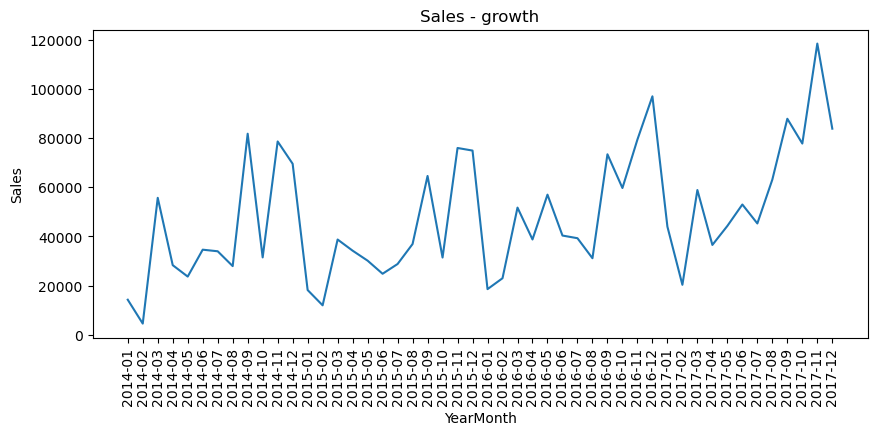

In [73]:
monthly_sales_df = monthly_sales.reset_index()
monthly_sales_df["YearMonth"] = monthly_sales_df["YearMonth"].astype(str)
plt.figure(figsize=(10, 4))
sns.lineplot(data=monthly_sales_df, x="YearMonth", y="Sales")
plt.title("Sales - growth")
plt.xticks(rotation=90)
plt.show()

## Business Insights

**1. Sales are growing but margins are under pressure**
Total sales grew significantly from 2014 to 2017, with monthly peaks increasing from ~$80k to ~$120k. However, this growth does not translate into proportional profit growth: aggressive discounting erodes 
margins and generates loss-making orders even at high sales volumes, suggesting the business may be buying revenue at the cost of profitability.

**2. Discounts above 30% systematically destroy value**
Grouping orders by discount level reveals a clear point: average profit turns negative at discounts ≥ 30%, with a loss of $45 per order at 30% and worsening losses at higher levels (up to -$310 average at 50% discount). 
Approximately 30% of all orders carry discounts at or above this threshold, meaning a significant share of transactions actively destroys value rather than contributing to profit.

**3. Technology drives profit; Furniture is a structural drag**
Technology generates the highest average profit per order ($78.8), nearly 4x Office Supplies ($20.3) and 9x Furniture ($8.7). In total profit contribution, Technology and Office Supplies each exceed $100k, while Furniture contributes only ~$18k despite accounting for 21% of total orders. Furniture's combination of low unit margins and high discount exposure makes it the key area to investigate for margin improvement.

**4. Clear seasonal pattern with growing amplitude**
Monthly sales follow a consistent retail seasonality: peaks in November–December driven by holiday demand, depression in January–February. Notably, this pattern becomes more pronounced over time; the gap between peak and depression months widens from 2014 to 2017; suggesting increasing concentration of revenue in the holiday period, which may expose the business to seasonal risk.